In [6]:
Q = 10.0   # variansi noise proses — besar, curah hujan sangat tidak teratur
R = 1.0    # variansi noise pengukuran — kecil, ERA5 cukup akurat   

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/raw/bandung_rainfall_2010_2026.csv', parse_dates=['date'], index_col='date')
y = df['precipitation_mm'].values
print(f"Jumlah observasi: {len(y)}")
print(f"Mean: {y.mean():.2f}, Std: {y.std():.2f}")

Jumlah observasi: 5995
Mean: 7.66, Std: 10.26


In [4]:
def kalman_filter(y, phi, Q, R, mu0, P0):
    """
    Kalman Filter untuk scalar state-space model.
    
    State transition : X_t = phi * X_{t-1} + epsilon_t,  epsilon_t ~ N(0, Q)
    Observation      : Y_t = X_t + v_t,                  v_t ~ N(0, R)
    
    Parameters
    ----------
    y   : array observasi Y_1, ..., Y_n
    phi : koefisien state transition
    Q   : variansi noise proses
    R   : variansi noise pengukuran
    mu0 : mean awal X_0
    P0  : variansi awal X_0
    
    Returns
    -------
    mu_filtered : array mean posterior mu_{t|t} untuk setiap t
    P_filtered  : array variansi posterior P_{t|t} untuk setiap t
    K_gains     : array Kalman Gain K_t untuk setiap t
    """
    n = len(y)
    mu_filtered = np.zeros(n)
    P_filtered  = np.zeros(n)
    K_gains     = np.zeros(n)
    
    mu = mu0
    P  = P0
    
    for t in range(n):
        # --- Predict ---
        mu_pred = phi * mu
        P_pred  = phi**2 * P + Q
        
        # --- Update ---
        K         = P_pred / (P_pred + R)
        mu        = mu_pred + K * (y[t] - mu_pred)
        P         = (1 - K) * P_pred
        
        mu_filtered[t] = mu
        P_filtered[t]  = P
        K_gains[t]     = K
    
    return mu_filtered, P_filtered, K_gains

In [7]:
# Inisialisasi
mu0 = y[0]        # tebakan awal: nilai observasi pertama
P0  = y.var()     # ketidakpastian awal: variansi seluruh data
phi = 0.3886      # dari estimasi AR(2) Fase 2, kita pakai phi_1 sebagai approx

# Jalankan filter
mu_filtered, P_filtered, K_gains = kalman_filter(y, phi, Q, R, mu0, P0)

print(f"Kalman Gain rata-rata : {K_gains.mean():.4f}")
print(f"Kalman Gain min       : {K_gains.min():.4f}")
print(f"Kalman Gain max       : {K_gains.max():.4f}")

Kalman Gain rata-rata : 0.9102
Kalman Gain min       : 0.9102
Kalman Gain max       : 0.9628


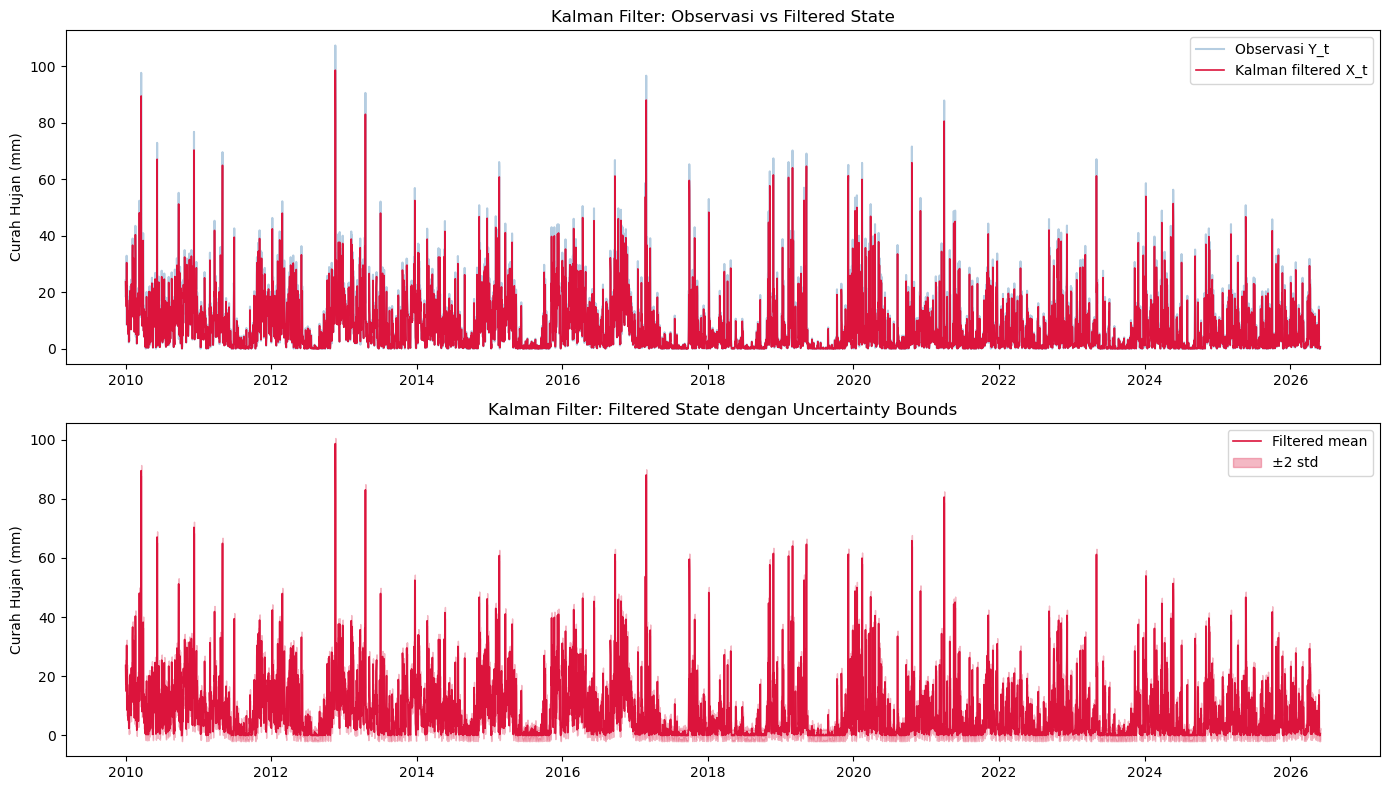

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: observasi vs filtered state
axes[0].plot(df.index, y, alpha=0.4, color='steelblue', label='Observasi Y_t')
axes[0].plot(df.index, mu_filtered, color='crimson', linewidth=1.2, label='Kalman filtered X_t')
axes[0].set_title('Kalman Filter: Observasi vs Filtered State')
axes[0].set_ylabel('Curah Hujan (mm)')
axes[0].legend()

# Plot 2: uncertainty (2 std bounds)
axes[1].plot(df.index, mu_filtered, color='crimson', linewidth=1.2, label='Filtered mean')
axes[1].fill_between(df.index,
                     mu_filtered - 2*np.sqrt(P_filtered),
                     mu_filtered + 2*np.sqrt(P_filtered),
                     alpha=0.3, color='crimson', label='±2 std')
axes[1].set_title('Kalman Filter: Filtered State dengan Uncertainty Bounds')
axes[1].set_ylabel('Curah Hujan (mm)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/kalman_filtered.png', dpi=150)
plt.show()

In [9]:
def kalman_forecast(y, phi, Q, R, mu0, P0):
    """
    Walk-forward 1-step forecast menggunakan Kalman Filter.
    Untuk setiap t, forecast Y_{t+1} menggunakan data Y_1,...,Y_t.
    """
    n = len(y)
    forecasts = np.zeros(n - 1)

    mu = mu0
    P  = P0

    for t in range(n - 1):
        # Update dengan observasi saat ini
        P_pred  = phi**2 * P + Q
        K       = P_pred / (P_pred + R)
        mu      = mu + K * (y[t] - phi * mu)
        P       = (1 - K) * P_pred

        # Forecast satu langkah ke depan (tanpa observasi)
        forecasts[t] = phi * mu

    return forecasts

forecasts_kf = kalman_forecast(y, phi, Q, R, mu0, P0)
print(f"Forecast pertama : {forecasts_kf[0]:.4f}")
print(f"Forecast terakhir: {forecasts_kf[-1]:.4f}")

Forecast pertama : 14.9400
Forecast terakhir: 0.6317


In [10]:
# Gunakan 80/20 split yang sama dengan Fase 2
train_size = int(len(y) * 0.8)
y_test = y[train_size:]
forecasts_test = forecasts_kf[train_size - 1 : len(y) - 1]

# Metrik
mae_kf  = np.mean(np.abs(y_test - forecasts_test))
rmse_kf = np.sqrt(np.mean((y_test - forecasts_test)**2))

# Naive baseline (sama dengan Fase 2)
mae_naive  = np.mean(np.abs(np.diff(y_test)))
rmse_naive = np.sqrt(np.mean(np.diff(y_test)**2))

skill_score = 1 - (rmse_kf / rmse_naive)

print(f"=== Kalman Filter ===")
print(f"MAE        : {mae_kf:.2f} mm")
print(f"RMSE       : {rmse_kf:.2f} mm")
print(f"Skill Score: {skill_score:.3f}")
print()
print(f"=== Baseline Fase 2 ===")
print(f"ARMA(2,1) MAE : 5.08 mm")
print(f"ARMA(2,1) RMSE: 7.65 mm")
print(f"ARMA(2,1) Skill Score: 0.079")

=== Kalman Filter ===
MAE        : 4.93 mm
RMSE       : 8.03 mm
Skill Score: 0.127

=== Baseline Fase 2 ===
ARMA(2,1) MAE : 5.08 mm
ARMA(2,1) RMSE: 7.65 mm
ARMA(2,1) Skill Score: 0.079


In [11]:
# Hitung innovation sequence
innovations = np.zeros(len(y))
mu = mu0
P  = P0

for t in range(len(y)):
    P_pred          = phi**2 * P + Q
    K               = P_pred / (P_pred + R)
    innovations[t]  = y[t] - phi * mu        # Y_t - mu_{t|t-1}
    mu              = mu + K * innovations[t]
    P               = (1 - K) * P_pred

print(f"Mean innovation  : {innovations.mean():.4f}")
print(f"Std innovation   : {innovations.std():.4f}")

Mean innovation  : -0.0043
Std innovation   : 9.1909


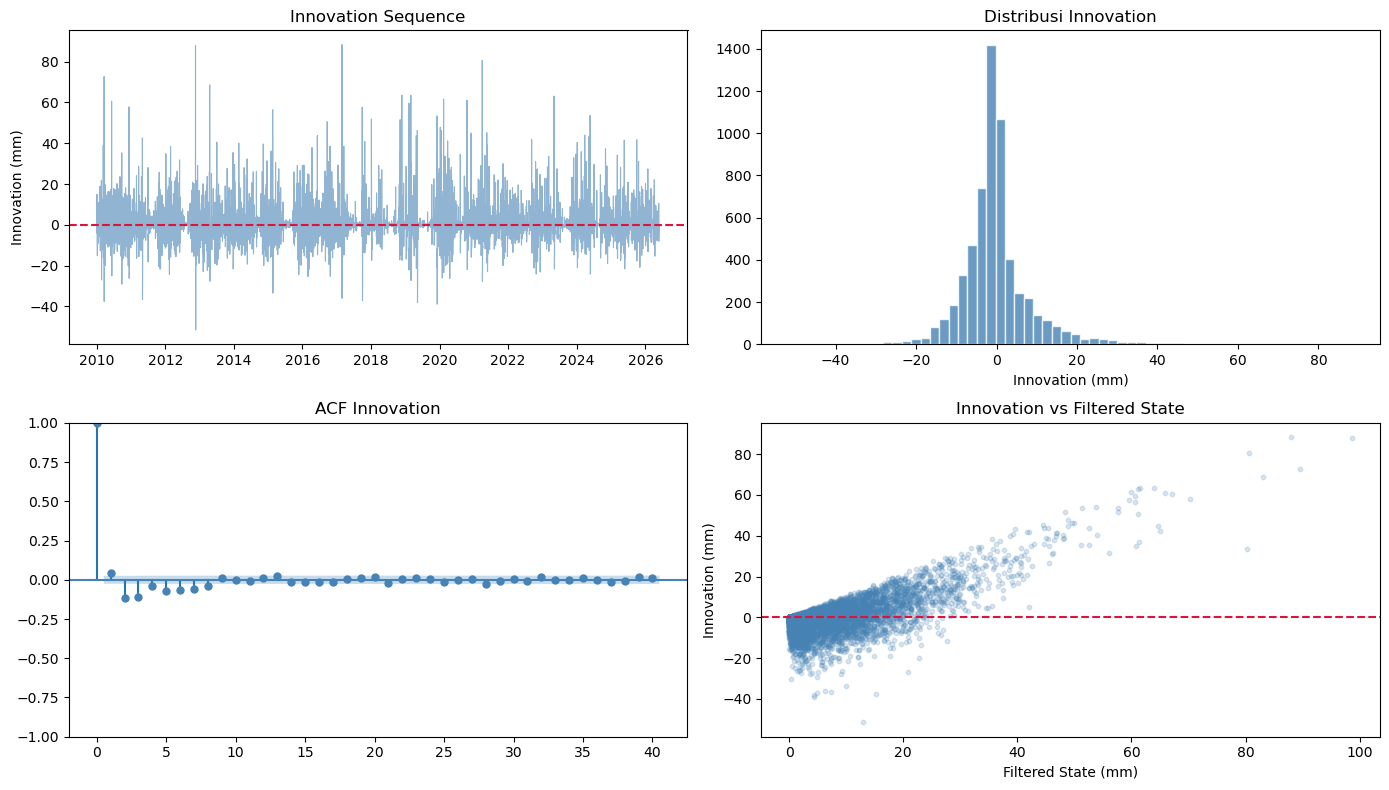

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1: Innovation sequence
axes[0, 0].plot(df.index, innovations, alpha=0.6, color='steelblue', linewidth=0.8)
axes[0, 0].axhline(0, color='crimson', linestyle='--')
axes[0, 0].set_title('Innovation Sequence')
axes[0, 0].set_ylabel('Innovation (mm)')

# Plot 2: Histogram
axes[0, 1].hist(innovations, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Distribusi Innovation')
axes[0, 1].set_xlabel('Innovation (mm)')

# Plot 3: ACF innovation
plot_acf(innovations, lags=40, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('ACF Innovation')

# Plot 4: Innovation vs fitted (heteroskedastisitas)
axes[1, 1].scatter(mu_filtered, innovations, alpha=0.2, color='steelblue', s=10)
axes[1, 1].axhline(0, color='crimson', linestyle='--')
axes[1, 1].set_title('Innovation vs Filtered State')
axes[1, 1].set_xlabel('Filtered State (mm)')
axes[1, 1].set_ylabel('Innovation (mm)')

plt.tight_layout()
plt.savefig('../outputs/kalman_residuals.png', dpi=150)
plt.show()

In [13]:
from itertools import product

# Grid nilai yang akan dicoba
Q_values = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
R_values = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0]

best_rmse = np.inf
best_Q, best_R = None, None
results = []

for Q_try, R_try in product(Q_values, R_values):
    forecasts_try = kalman_forecast(y, phi, Q_try, R_try, mu0, P0)
    forecasts_try_test = forecasts_try[train_size - 1 : len(y) - 1]
    rmse_try = np.sqrt(np.mean((y_test - forecasts_try_test)**2))
    mae_try  = np.mean(np.abs(y_test - forecasts_try_test))
    results.append((Q_try, R_try, rmse_try, mae_try))
    
    if rmse_try < best_rmse:
        best_rmse = rmse_try
        best_Q, best_R = Q_try, R_try

print(f"Q terbaik  : {best_Q}")
print(f"R terbaik  : {best_R}")
print(f"RMSE terbaik: {best_rmse:.4f} mm")

Q terbaik  : 0.1
R terbaik  : 0.1
RMSE terbaik: 7.9722 mm


In [14]:
Q_values_fine = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
R_values_fine = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

best_rmse_fine = np.inf
best_Q_fine, best_R_fine = None, None

for Q_try, R_try in product(Q_values_fine, R_values_fine):
    forecasts_try = kalman_forecast(y, phi, Q_try, R_try, mu0, P0)
    forecasts_try_test = forecasts_try[train_size - 1 : len(y) - 1]
    rmse_try = np.sqrt(np.mean((y_test - forecasts_try_test)**2))
    
    if rmse_try < best_rmse_fine:
        best_rmse_fine = rmse_try
        best_Q_fine, best_R_fine = Q_try, R_try

print(f"Q terbaik  : {best_Q_fine}")
print(f"R terbaik  : {best_R_fine}")
print(f"RMSE terbaik: {best_rmse_fine:.4f} mm")

Q terbaik  : 0.001
R terbaik  : 0.001
RMSE terbaik: 7.9722 mm
